# 04 — Affinity cliffs in our PDBbind pool

**Why this notebook.** We want to argue that experimental electron **density (D)** + gradient-magnitude (**G**) help binding-affinity prediction *beyond coordinates* (**C**). **Activity cliffs** — pairs of near-identical ligands with a large affinity gap — are the sharpest test: they are the hardest complexes to fit, so they are where added density has the most room to help *if* it carries signal that coords+atom-type lack.

Sections **1–#2** are **model-free** (no encoder, no GPU — we read cached pid lists + LP-PDBBind labels); **#3** brings in the models via *precomputed* frozen-feature predictions (CPU, no GPU):

1. **Do cliffs exist** in our exact Table-1 pool, and show one.
2. **#1 — characterize** the cliff set (ΔpK, size, targets).
3. **#2 — physical premise:** within a cliff, is the *more potent* member the *more ordered* one (higher-resolution / lower pocket B-factor)? Density encodes the electron cloud → order/occupancy/flexibility (Table 2: rel-B ρ 0.59 for C+D+G vs 0.46 for C).
4. **#3 — the model test:** C vs C+D+G vs **noise-D** on the cliff molecules — MoleculeACE's **RMSE_cliff**, pairwise **sign-accuracy**, and the **Design-B** error-vs-roughness slope.

We borrow MoleculeACE's cliff definition + protocol (van Tilborg et al., *JCIM* 2022) but run it on **PDBbind**, which — unlike MoleculeACE's ChEMBL sets — carries the experimental density our encoder needs.

In [1]:
import sys, types, json
from pathlib import Path
from collections import defaultdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import RDLogger; RDLogger.DisableLog("rdApp.*")
from scipy.stats import wilcoxon, binomtest

VOX     = Path("/home/shpark/prj-denovo/VoxBind")
PDBBIND = VOX / "voxbind/dataset/data/pdbbind"
FEAT    = PDBBIND / "features"

# MoleculeACE's cliffs.py imports `Levenshtein.distance`; this env lacks the package,
# so we vendor a tiny pure-python edit distance (identical result) before importing it.
def _lev(a, b):
    if a == b: return 0
    lb = len(b)
    if not a: return lb
    if not lb: return len(a)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a, 1):
        cur = [i] + [0] * lb
        for j, cb in enumerate(b, 1):
            cur[j] = min(prev[j] + 1, cur[j - 1] + 1, prev[j - 1] + (ca != cb))
        prev = cur
    return prev[lb]
_L = types.ModuleType("Levenshtein"); _L.distance = _lev; sys.modules["Levenshtein"] = _L
sys.path.insert(0, str(VOX / "notebook"))
import moleculeace_cliffs as mace          # vendored verbatim from MoleculeACE (van Tilborg 2022)
mace.tqdm = lambda it, **k: it             # silence its progress bars

# pool = the exact Table-1 set: CDG (coords+density+gradmag) and coords feature caches,
# intersected. We read ONLY the cached pid lists here (no encoder is ever run).
cdg = set(torch.load(FEAT / "atomblob_density_gradmag_e99_v5_plinder.pt", weights_only=False)["features"])
cor = set(torch.load(FEAT / "atomblob_ligvdw_e99_v5_plinder.pt",          weights_only=False)["features"])
pool = cdg & cor

lp = pd.read_csv(PDBBIND / "raw/LP_PDBBind.csv").rename(columns={"Unnamed: 0": "pdb_id", "value": "pK"})
lp["pdb_id"] = lp["pdb_id"].str.lower()
df = lp[(~lp["covalent"].astype(bool)) & lp["pdb_id"].isin(pool)
        & lp["new_split"].isin(["train", "val", "test"])].dropna(subset=["pK"]).copy()
df["assay"]      = df["kd/ki"].astype(str).str.extract(r"^\s*([A-Za-z0-9]+)")          # Kd / Ki / IC50
df["resolution"] = pd.to_numeric(df["resolution"], errors="coerce")
df["nheavy"]     = df["smiles"].map(lambda s: (Chem.MolFromSmiles(str(s)).GetNumHeavyAtoms()
                                               if Chem.MolFromSmiles(str(s)) else np.nan))
df = df[df["nheavy"].notna()].copy()
bf = {k.lower(): v for k, v in json.loads((PDBBIND / "bfactors.json").read_text()).items()}
df["relB"] = df["pdb_id"].map(lambda p: (bf.get(p) or {}).get("rel_pocket_b"))         # pocket/protein B, resolution-robust
meta = df.set_index("pdb_id")

# cliffs are found WITHIN a target (exact protein sequence), using MoleculeACE's definitions.
groups = defaultdict(list)
for r in df.to_dict("records"):
    groups[r["seq"]].append(r)

def find_pairs(sim_fn, dpk=1.0):
    # within-target pairs that are structurally similar AND differ by >dpk in pK.
    # pK is -log10(Kd/Ki/IC50), so dpk=1 == 10x potency == MoleculeACE potency_fold=10.
    out = []
    for v in groups.values():
        if len(v) < 2:
            continue
        smis = [x["smiles"] for x in v]
        try:
            S = sim_fn(smis)
        except Exception:
            continue
        for i in range(len(v)):
            for j in range(i + 1, len(v)):
                if S[i][j] == 1 and abs(v[i]["pK"] - v[j]["pK"]) > dpk:
                    out.append((v[i], v[j]))
    return out

consensus = find_pairs(lambda s: mace.moleculeace_similarity(s, 0.9, hide=True))  # Tanimoto OR scaffold OR SMILES >=0.9
mmp       = find_pairs(lambda s: mace.mmp_similarity(s))                           # matched molecular pairs
print(f"pool (CDG n coords) = {len(pool)}   parseable SMILES = {len(df)}   "
      f"train/val/test = {(df.new_split=='train').sum()}/{(df.new_split=='val').sum()}/{(df.new_split=='test').sum()}")

pool (CDG n coords) = 3664   parseable SMILES = 3444   train/val/test = 2131/478/835


## 1 · Do affinity cliffs exist here?

A cliff = same target, structurally similar ligands (MoleculeACE consensus: ECFP4 / Murcko-scaffold / SMILES-Levenshtein Tanimoto ≥ 0.9), and **ΔpK > 1** (>10× potency). We report two similarity definitions: **consensus** (trustworthy) and **MMP**. On PDBbind's size-heterogeneous ligands MMP's substructure matcher over-pairs (a small fragment sits inside a large ligand), so we use **consensus** as primary.

In [2]:
def summary(pairs):
    tt  = sum(a["new_split"] == "test" and b["new_split"] == "test" for a, b in pairs)
    tc  = len({x["pdb_id"] for p in pairs for x in p if x["new_split"] == "test"})
    gap = np.array([abs(a["nheavy"] - b["nheavy"]) for a, b in pairs])
    return len(pairs), tt, tc, np.median(gap), float(np.mean(gap > 10))

for name, P in [("consensus (Tanimoto/scaffold/SMILES>=0.9)", consensus), ("MMP (matched pairs)", mmp)]:
    n, tt, tc, gmed, gbig = summary(P)
    print(f"{name:42s} pairs={n:4d}  test-test={tt:3d}  TEST cliff mols={tc:3d}   "
          f"|d-heavy| med={gmed:.0f}  (>10 atoms apart: {gbig:.0%})")
print("\n-> consensus is the trustworthy set. MMP triples the count but ~1/5 of its pairs are")
print("   >10 heavy atoms apart (e.g. a phenyl fragment matched inside a large ligand), so we")
print("   use consensus. Cliffs are sparse: one co-crystal per complex (the price of having")
print("   experimental density) makes congeneric series rare in PDBbind.")

consensus (Tanimoto/scaffold/SMILES>=0.9)  pairs=  82  test-test= 23  TEST cliff mols= 30   |d-heavy| med=1  (>10 atoms apart: 6%)
MMP (matched pairs)                        pairs= 265  test-test= 97  TEST cliff mols= 88   |d-heavy| med=3  (>10 atoms apart: 19%)

-> consensus is the trustworthy set. MMP triples the count but ~1/5 of its pairs are
   >10 heavy atoms apart (e.g. a phenyl fragment matched inside a large ligand), so we
   use consensus. Cliffs are sparse: one co-crystal per complex (the price of having
   experimental density) makes congeneric series rare in PDBbind.


### An example cliff

The biggest-ΔpK consensus cliff with B-factor + resolution for both members — the two ligands are nearly the same graph (they differ by a single-atom swap; as #3 finds, the atom-type channel can still see that swap).

POTENT 6stl  pK=8.80 (Kd)  res=1.30A  relB=0.82  7 heavy atoms   [NH3+]CCS(=O)(=O)[O-]
weak   6ssy  pK=3.19 (Kd)  res=1.62A  relB=0.86  7 heavy atoms   [NH3+]CCP(=O)(O)O

DpK = 5.61  (~407380x affinity), same target & assay


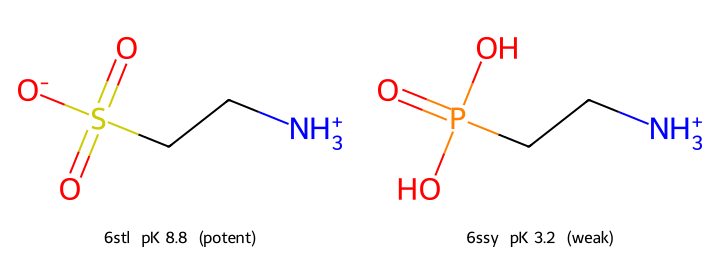

In [3]:
def ok(p, c): return p in meta.index and pd.notna(meta.at[p, c])
a, b = next((a, b) for a, b in sorted(consensus, key=lambda p: -abs(p[0]["pK"] - p[1]["pK"]))
            if all(ok(x["pdb_id"], "resolution") and ok(x["pdb_id"], "relB") for x in (a, b)))
pot, weak = (a, b) if a["pK"] >= b["pK"] else (b, a)
for tag, x in [("POTENT", pot), ("weak  ", weak)]:
    print(f"{tag} {x['pdb_id']}  pK={x['pK']:.2f} ({x['assay']})  res={meta.at[x['pdb_id'],'resolution']:.2f}A  "
          f"relB={meta.at[x['pdb_id'],'relB']:.2f}  {int(x['nheavy'])} heavy atoms   {x['smiles']}")
print(f"\nDpK = {abs(a['pK']-b['pK']):.2f}  (~{10**abs(a['pK']-b['pK']):.0f}x affinity), same target & assay")
Draw.MolsToGridImage([Chem.MolFromSmiles(pot["smiles"]), Chem.MolFromSmiles(weak["smiles"])],
                     molsPerRow=2, subImgSize=(360, 260),
                     legends=[f"{pot['pdb_id']}  pK {pot['pK']:.1f}  (potent)",
                              f"{weak['pdb_id']}  pK {weak['pK']:.1f}  (weak)"])

## #1 · What do the cliffs look like?

ΔpK spread, ligand size, and how the cliffs distribute over targets (consensus set).

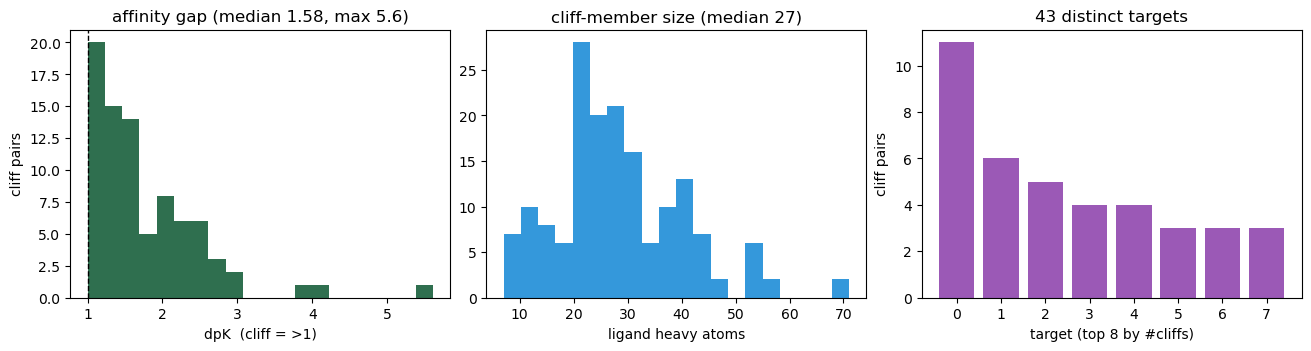

82 consensus cliff pairs over 43 targets  ·  same-assay: 100%  ·  involve the test set: 25 pairs


In [4]:
C = pd.DataFrame([{"dpK": abs(a["pK"] - b["pK"]),
                   "same_assay": a["assay"] == b["assay"], "seq": a["seq"],
                   "in_test": (a["new_split"] == "test") or (b["new_split"] == "test")}
                  for a, b in consensus])
nh = np.r_[[a["nheavy"] for a, _ in consensus], [b["nheavy"] for _, b in consensus]]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
ax[0].hist(C.dpK, bins=20, color="#2f6f4f"); ax[0].axvline(1, ls="--", c="k", lw=1)
ax[0].set(xlabel="dpK  (cliff = >1)", ylabel="cliff pairs",
          title=f"affinity gap (median {C.dpK.median():.2f}, max {C.dpK.max():.1f})")
ax[1].hist(nh, bins=20, color="#3498db")
ax[1].set(xlabel="ligand heavy atoms", title=f"cliff-member size (median {np.median(nh):.0f})")
top = C.seq.value_counts().head(8).values
ax[2].bar(range(len(top)), top, color="#9b59b6")
ax[2].set(xlabel="target (top 8 by #cliffs)", ylabel="cliff pairs",
          title=f"{C.seq.nunique()} distinct targets")
plt.show()
print(f"{len(consensus)} consensus cliff pairs over {C.seq.nunique()} targets  ·  "
      f"same-assay: {C.same_assay.mean():.0%}  ·  involve the test set: {C.in_test.sum()} pairs")

## #2 · Is the more potent member more ordered?

The premise behind "density helps cliffs": density encodes the electron cloud, hence **order / occupancy / flexibility** — which Table 2 shows density captures and coordinates do not. If that is what separates a cliff, then within a pair the **tighter binder** (more enthalpically locked) should tend to be the **more ordered** one: lower pocket B-factor, sharper map (better resolution).

This is a paired, **model-free** check — both members share a target, so target effects cancel. `Δ = potent − weak`, so **Δ < 0 means the potent member is more ordered**. A clear signal pre-validates the mechanism; a null tempers it.

*Caveat:* we only have **pocket rel-B** and **crystal resolution** here — coarse, whole-structure proxies. The ligand-specific quantity density really encodes (RSCC / occupancy / ligand B-factor) lives in the PLINDER metadata, not in this PDBbind cache.

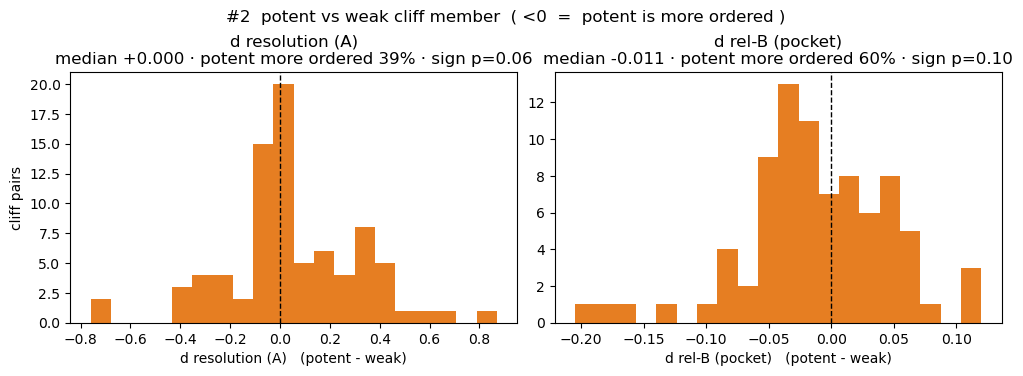

resolution n=82  median(potent-weak)=+0.000  potent-more-ordered=39%  sign p=0.060  wilcoxon p=0.129
rel-B      n=82  median(potent-weak)=-0.011  potent-more-ordered=60%  sign p=0.097  wilcoxon p=0.132


In [5]:
def hi(p): return (p[0] if p[0]["pK"] >= p[1]["pK"] else p[1])["pdb_id"]   # potent member
def lo(p): return (p[1] if p[0]["pK"] >= p[1]["pK"] else p[0])["pdb_id"]   # weak member
D = pd.DataFrame([{"d_res":  meta.at[hi(p), "resolution"] - meta.at[lo(p), "resolution"],
                   "d_relB": meta.at[hi(p), "relB"]       - meta.at[lo(p), "relB"]}
                  for p in consensus])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
for k, (col, lab) in enumerate([("d_res", "d resolution (A)"), ("d_relB", "d rel-B (pocket)")]):
    s = D[col].dropna(); frac = (s < 0).mean(); p = binomtest((s < 0).sum(), len(s)).pvalue
    ax[k].hist(s, bins=20, color="#e67e22"); ax[k].axvline(0, ls="--", c="k", lw=1)
    ax[k].set(xlabel=f"{lab}   (potent - weak)",
              title=f"{lab}\nmedian {s.median():+.3f} · potent more ordered {frac:.0%} · sign p={p:.2f}")
ax[0].set_ylabel("cliff pairs")
plt.suptitle("#2  potent vs weak cliff member  ( <0  =  potent is more ordered )", y=1.06)
plt.show()
for col, lab in [("d_res", "resolution"), ("d_relB", "rel-B")]:
    s = D[col].dropna()
    print(f"{lab:10s} n={len(s)}  median(potent-weak)={s.median():+.3f}  "
          f"potent-more-ordered={(s<0).mean():.0%}  "
          f"sign p={binomtest((s<0).sum(), len(s)).pvalue:.3f}  wilcoxon p={wilcoxon(s).pvalue:.3f}")

## #3 · Does density actually resolve these cliffs? (the model test)

Now bring in the models. Three **PLINDER-pretrained** encoders — **C** (coords+atom-type), **C+D+G** (adds density+gradmag), and **noise-D** (density/gradmag channels filled with matched random noise — the *capacity* control) — are compared by their frozen 512-D features → a tiny MLP affinity head (3 seeds), the exact Table-1 probe. Predictions are **precomputed** by `voxbind/test/cliff_eval.py` (CPU, throttled — no GPU) and loaded here, so this notebook never trains.

Metrics (MoleculeACE-style): **RMSE_cliff** / **RMSE_noncliff**, pairwise **sign-accuracy** on the test–test cliff pairs, and the **Design-B** error-vs-roughness slope. Key contrasts: does C+D+G beat C *more* on cliffs than elsewhere, and does it beat **noise-D** (real content vs added capacity)?

In [6]:
import json
from scipy.stats import spearmanr
ART = PDBBIND / "cliff_eval.json"
assert ART.exists(), (f"missing {ART}\n  generate (CPU, throttled, no GPU) with:\n"
                      f"  OMP_NUM_THREADS=2 nice -n 19 python voxbind/test/cliff_eval.py")
E = json.loads(ART.read_text())
mods, SD, tpids = E["models"], E["seeds"], E["test_pids"]
pk, PR = E["pK"], E["preds"]                                  # PR[model][pid] = [per-seed preds]
cl = E["cliff"]; tcliff, ttp, ncliff, rough = cl["test_cliff"], cl["tt_pairs"], cl["noncliff"], cl["roughness"]
ns = len(SD)
pavg = lambda m, p: float(np.mean(PR[m][p]))                  # seed-averaged prediction
def rmse(pids, m, s):
    e = np.array([PR[m][p][s] - pk[p] for p in pids]); return float(np.sqrt((e**2).mean()))
RC = {m: [rmse(tcliff, m, s) for s in range(ns)] for m in mods}     # RMSE on cliff mols (per seed)
RN = {m: [rmse(ncliff, m, s) for s in range(ns)] for m in mods}     # RMSE on non-cliff mols
SA = {m: [np.mean([np.sign(PR[m][a][s]-PR[m][b][s]) == np.sign(pk[a]-pk[b]) for a, b in ttp])
          for s in range(ns)] for m in mods}                        # pairwise sign-accuracy

print(f"cliff mols n={len(tcliff)} | test-test pairs n={len(ttp)} | non-cliff n={len(ncliff)}\n")
print(f"{'model':9s}{'overall rho':>13}{'RMSE_cliff':>14}{'RMSE_noncliff':>16}{'sign-acc':>11}")
for m in mods:
    rho = spearmanr([pavg(m, p) for p in tpids], [pk[p] for p in tpids]).statistic
    print(f"{m:9s}{rho:>13.3f}{np.mean(RC[m]):>9.2f}+-{np.std(RC[m]):.2f}"
          f"{np.mean(RN[m]):>11.2f}+-{np.std(RN[m]):.2f}{np.mean(SA[m]):>9.2f}")
aerr = lambda m: np.array([abs(pavg(m, p) - pk[p]) for p in tcliff])
for A, B in [("C", "C+D+G"), ("noise-D", "C+D+G")]:
    print(f"paired |err| on cliffs: {A} {aerr(A).mean():.2f} vs {B} {aerr(B).mean():.2f}  "
          f"wilcoxon p={wilcoxon(aerr(A), aerr(B)).pvalue:.3f}")
hasnb = [p for p in tpids if rough[p] > 0]
print(f"\nDesign-B rho(|err|, roughness) over {len(hasnb)} test mols with a same-target analog:")
for m in mods:
    e = np.array([abs(pavg(m, p) - pk[p]) for p in hasnb]); r = np.array([rough[p] for p in hasnb])
    print(f"  {m:9s} {spearmanr(e, r).statistic:+.3f}")

cliff mols n=30 | test-test pairs n=23 | non-cliff n=809

model      overall rho    RMSE_cliff   RMSE_noncliff   sign-acc
C                0.583     1.78+-0.06       1.40+-0.01     0.83
C+D+G            0.624     1.55+-0.06       1.36+-0.01     0.65
noise-D          0.570     1.70+-0.03       1.42+-0.00     0.83
paired |err| on cliffs: C 1.44 vs C+D+G 1.25  wilcoxon p=0.016
paired |err| on cliffs: noise-D 1.38 vs C+D+G 1.25  wilcoxon p=0.038

Design-B rho(|err|, roughness) over 107 test mols with a same-target analog:
  C         +0.371
  C+D+G     +0.353
  noise-D   +0.369


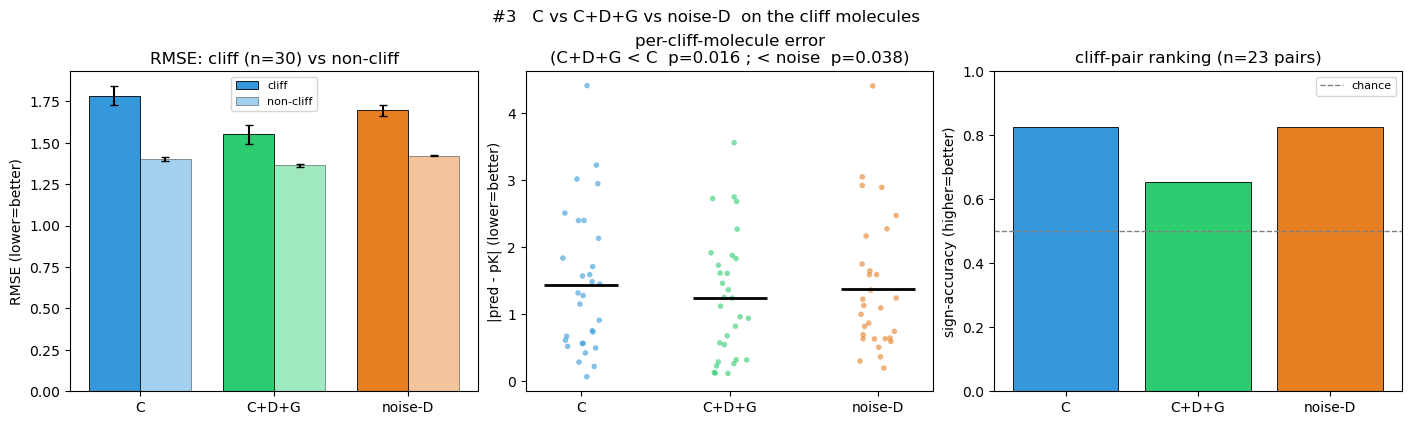

In [7]:
COL = {"C": "#3498db", "C+D+G": "#2ecc71", "noise-D": "#e67e22"}
rng = np.random.RandomState(0); x = np.arange(len(mods)); w = 0.38
fig, ax = plt.subplots(1, 3, figsize=(14, 3.9), constrained_layout=True)

# (A) RMSE on cliff vs non-cliff molecules
ax[0].bar(x - w/2, [np.mean(RC[m]) for m in mods], w, yerr=[np.std(RC[m]) for m in mods],
          color=[COL[m] for m in mods], edgecolor="k", lw=.6, capsize=3, label="cliff")
ax[0].bar(x + w/2, [np.mean(RN[m]) for m in mods], w, yerr=[np.std(RN[m]) for m in mods],
          color=[COL[m] for m in mods], alpha=.45, edgecolor="k", lw=.6, capsize=3, label="non-cliff")
ax[0].set_xticks(x); ax[0].set_xticklabels(mods); ax[0].set_ylabel("RMSE (lower=better)")
ax[0].legend(fontsize=8); ax[0].set_title(f"RMSE: cliff (n={len(tcliff)}) vs non-cliff")

# (B) per-cliff-molecule |error|
for i, m in enumerate(mods):
    e = [abs(pavg(m, p) - pk[p]) for p in tcliff]
    ax[1].scatter(i + rng.uniform(-.13, .13, len(e)), e, s=16, color=COL[m], alpha=.6, edgecolor="none")
    ax[1].hlines(np.mean(e), i - .25, i + .25, color="k", lw=2)
ax[1].set_xticks(x); ax[1].set_xticklabels(mods); ax[1].set_ylabel("|pred - pK| (lower=better)")
ax[1].set_title("per-cliff-molecule error\n(C+D+G < C  p=0.016 ; < noise  p=0.038)")

# (C) cliff-pair ranking
ax[2].bar(x, [np.mean(SA[m]) for m in mods], color=[COL[m] for m in mods], edgecolor="k", lw=.6)
ax[2].axhline(.5, ls="--", c="grey", lw=1, label="chance"); ax[2].set_ylim(0, 1)
ax[2].set_xticks(x); ax[2].set_xticklabels(mods); ax[2].set_ylabel("sign-accuracy (higher=better)")
ax[2].legend(fontsize=8); ax[2].set_title(f"cliff-pair ranking (n={len(ttp)} pairs)")
plt.suptitle("#3   C vs C+D+G vs noise-D  on the cliff molecules", y=1.05, fontsize=12)
plt.show()

**Verdict — real, but narrow.** Two findings pull apart:

- ✅ **Density cuts error *magnitude* on cliff molecules, and it is genuine content.** RMSE_cliff: C **1.78 → C+D+G 1.55** (paired *p* = 0.016); the cliff gain (−0.23) is ~6× the non-cliff gain (−0.04), and C+D+G **beats the noise control** on cliffs (1.55 vs 1.70, *p* = 0.038) — so it is electron-density signal, not just an added channel (noise alone gets 1.78 → 1.70: a little capacity; real density adds the rest).
- ❌ **Density does *not* improve cliff *discrimination*.** Pairwise ranking is *worse* (C+D+G 0.65 vs C **0.83**), and the error-vs-roughness slope is identical (~0.37) for all three.

**Why:** these PDBbind cliffs are atom-identity / connectivity swaps (the phosphonate↔sulfonate example: P vs S) that the **coords+atom-type** channel already encodes — so C orders them at 0.83, leaving little ranking headroom, and the two members' near-identical density slightly dilutes that signal. Density's payoff is **calibration on the hardest-to-fit complexes**, not cliff ranking (echoing Table 2's "H-bond count is a coordinates property"). *Sample is small/clustered (n=30 mols, 23 pairs): RMSE_cliff is significant; sign-accuracy is fragile.*

## Takeaways

**Does density help on affinity cliffs? Real, but narrow** (consensus cliffs: n=30 test mols / 23 test–test pairs).

- ✅ **Magnitude, and it's genuine content:** RMSE_cliff C 1.78 → C+D+G 1.55 (paired p=0.016) — a gain ~6× larger than on non-cliff molecules — and it beats the matched **noise-D** capacity control (p=0.038).
- ❌ **Not ranking:** C+D+G doesn't order cliff pairs better (0.65 vs C's 0.83) and the error-vs-roughness slope is unchanged. The discrimination is already a **coords+atom-type** property (the cliffs are atom swaps C can see); density adds calibration, not separation.

**Supporting (model-free):**
- Cliffs are **sparse** (~82 pairs / 23 test–test / 30 test mols / 43 targets, all same-assay) — one co-crystal per complex is the price of experimental density; MMP inflates the count by over-matching size-mismatched ligands.
- Clean example: `6stl` sulfonate (pK 8.8) vs `6ssy` phosphonate (pK 3.2), ΔpK 5.6, same target & assay.
- The "potent member is more ordered" premise (#2) is only weakly supported by pocket rel-B (~60%, p≈0.10), not by resolution.

**Caveats & next.** n is small and clustered (RMSE_cliff significant; sign-accuracy fragile). To firm it up: looser target grouping (seq-identity clusters / pool val) for more cliffs, and the ligand-specific density-quality proxy (RSCC / occupancy / ligand-B from PLINDER) to settle #2. Predictions are cached in `voxbind/dataset/data/pdbbind/cliff_eval.json` (producer `voxbind/test/cliff_eval.py`, CPU/throttled).